In [1]:
import sys
import sklearn
import tensorflow as tf

import cv2
import pandas as pd
import numpy as np

import plotly.graph_objs as go
from plotly.offline import iplot
from matplotlib import pyplot as plt

In [2]:
tf.test.is_gpu_available()
strategy = tf.distribute.MirroredStrategy()
print('DEVICES AVAILABLE: {}'.format(strategy.num_replicas_in_sync))

DEVICES AVAILABLE: 1


In [3]:
tf.__version__

'2.1.0-rc0'

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Data Visualisation

In [5]:
import os

def get_data():
    return pd.read_csv('../input/deepfake-faces/metadata.csv')

In [6]:
meta=get_data()
meta.head()

,videoname,original_width,original_height,label,original
0,aznyksihgl.mp4,129,129,FAKE,xnojggkrxt.mp4
1,gkwmalrvcj.mp4,129,129,FAKE,hqqmtxvbjj.mp4
2,lxnqzocgaq.mp4,223,217,FAKE,xjzkfqddyk.mp4
3,itsbtrrelv.mp4,186,186,FAKE,kqvepwqxfe.mp4
4,ddvgrczjno.mp4,155,155,FAKE,pluadmqqta.mp4


In [7]:
meta.shape

(95634, 5)

In [8]:
len(meta[meta.label=='FAKE']),len(meta[meta.label=='REAL'])

(79341, 16293)

In [24]:
real_df = meta[meta["label"] == "REAL"]
fake_df = meta[meta["label"] == "FAKE"]
sample_size = 42000
fake_df = fake_df.sample(sample_size, random_state=42)
sample_meta = pd.concat([real_df, fake_df])

In [25]:
fake_df.shape, real_df.shape

((42000, 5), (16293, 5))

In [26]:
from sklearn.model_selection import train_test_split

Train_set, Test_set = train_test_split(sample_meta,test_size=0.2,random_state=42,stratify=sample_meta['label'])
Train_set, Val_set  = train_test_split(Train_set,test_size=0.15,random_state=42,stratify=Train_set['label'])

In [27]:
Train_set.shape,Val_set.shape,Test_set.shape

((39638, 5), (6996, 5), (11659, 5))

In [21]:
y = dict()

y[0] = []
y[1] = []

for set_name in (np.array(Train_set['label']), np.array(Val_set['label']), np.array(Test_set['label'])):
    y[0].append(np.sum(set_name == 'REAL'))
    y[1].append(np.sum(set_name == 'FAKE'))

trace0 = go.Bar(
    x=['Train Set', 'Validation Set', 'Test Set'],
    y=y[0],
    name='REAL',
    marker=dict(color='#33cc33'),
    opacity=0.7
)
trace1 = go.Bar(
    x=['Train Set', 'Validation Set', 'Test Set'],
    y=y[1],
    name='FAKE',
    marker=dict(color='#ff3300'),
    opacity=0.7
)

data = [trace0, trace1]
layout = go.Layout(
    title='Count of classes in each set',
    xaxis={'title': 'Set'},
    yaxis={'title': 'Count'}
)

fig = go.Figure(data, layout)
iplot(fig)

SystemError: <built-in function imread> returned NULL without setting an error

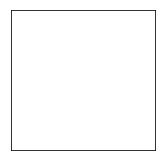

In [23]:
plt.figure(figsize=(15,15))
for cur,i in enumerate(Train_set.index[25:50]):
    plt.subplot(5,5,cur+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    plt.imshow(cv2.imread('../input/deepfake-faces/faces_224/'+Train_set.loc[i,'videoname'][:-4]+'.jpg'))
    
    if(Train_set.loc[i,'label']=='FAKE'):
        plt.xlabel('FAKE Image')
    else:
        plt.xlabel('REAL Image')
        
plt.show()

# Base Model

### Custom CNN Architecture

In [20]:
def retreive_dataset(set_name):
    images,labels=[],[]
    for (img, imclass) in zip(set_name['videoname'], set_name['label']):
        images.append(cv2.imread('../input/deepfake-faces/faces_224/'+img[:-4]+'.jpg'))
        if(imclass=='FAKE'):
            labels.append(1)
        else:
            labels.append(0)
    
    return np.array(images),np.array(labels)

In [ ]:
X_train,y_train=retreive_dataset(Train_set)
X_val,y_val=retreive_dataset(Val_set)
X_test,y_test=retreive_dataset(Test_set)

In [ ]:
from functools import partial

tf.random.set_seed(42) 
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")

model = tf.keras.Sequential([
    DefaultConv2D(filters=64, kernel_size=7, input_shape=[224, 224, 3]),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=1, activation="sigmoid")
])

In [17]:
model.compile(loss="binary_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 224, 224, 64)      9472      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 64)      0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 112, 112, 128)     73856     
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 112, 112, 128)     147584    
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 56, 56, 128)       0         
_________________________________________________________________
flatten (Flatten)            (None, 401408)            0         
_________________________________________________________________
dense (Dense)                (None, 128)               5

In [18]:
history = model.fit(X_train, y_train, epochs=5,batch_size=64,
                    validation_data=(X_val, y_val))

Train on 18247 samples, validate on 7821 samples
Epoch 1/5
18247/18247 [==============================] - 59s 3ms/sample - loss: 49.0771 - accuracy: 0.4986 - val_loss: 0.6931 - val_accuracy: 0.5103
Epoch 2/5
18247/18247 [==============================] - 54s 3ms/sample - loss: 0.7071 - accuracy: 0.5056 - val_loss: 0.6946 - val_accuracy: 0.4937
Epoch 3/5
18247/18247 [==============================] - 54s 3ms/sample - loss: 0.7155 - accuracy: 0.4986 - val_loss: 0.6930 - val_accuracy: 0.5040
Epoch 4/5
18247/18247 [==============================] - 54s 3ms/sample - loss: 0.7003 - accuracy: 0.5032 - val_loss: 0.6935 - val_accuracy: 0.4979
Epoch 5/5
18247/18247 [==============================] - 54s 3ms/sample - loss: 0.8087 - accuracy: 0.5022 - val_loss: 0.7284 - val_accuracy: 0.5038


In [19]:
score = model.evaluate(X_test, y_test)

6518/6518 [==============================] - 6s 966us/sample - loss: 0.7304 - accuracy: 0.4969


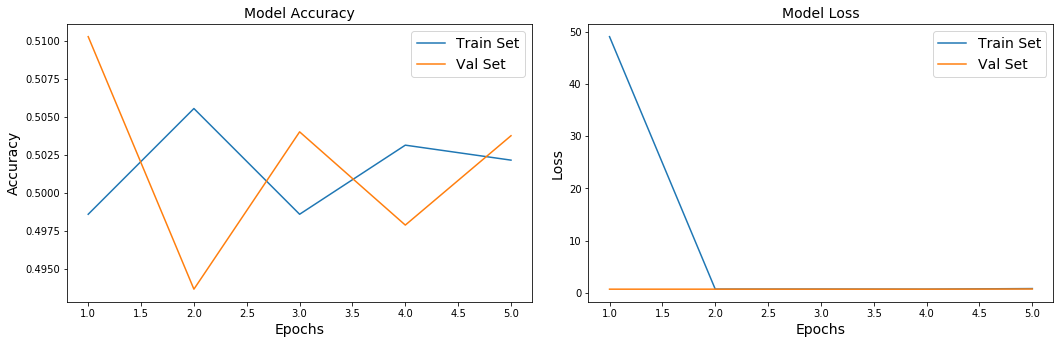

In [20]:
# plot model performance
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(history.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

**A baseline score is set here around ~51%**

# Pretrained Models for Transfer Learning

using Xception model for fine-tuning 

In [30]:
train_set_raw=tf.data.Dataset.from_tensor_slices((X_train,y_train))
valid_set_raw=tf.data.Dataset.from_tensor_slices((X_val,y_val))
test_set_raw=tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [32]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size_per_replica = 32
batch_size = batch_size_per_replica
preprocess = tf.keras.applications.xception.preprocess_input
train_set = train_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(tf.cast(X, tf.float32)), y)).batch(batch_size)

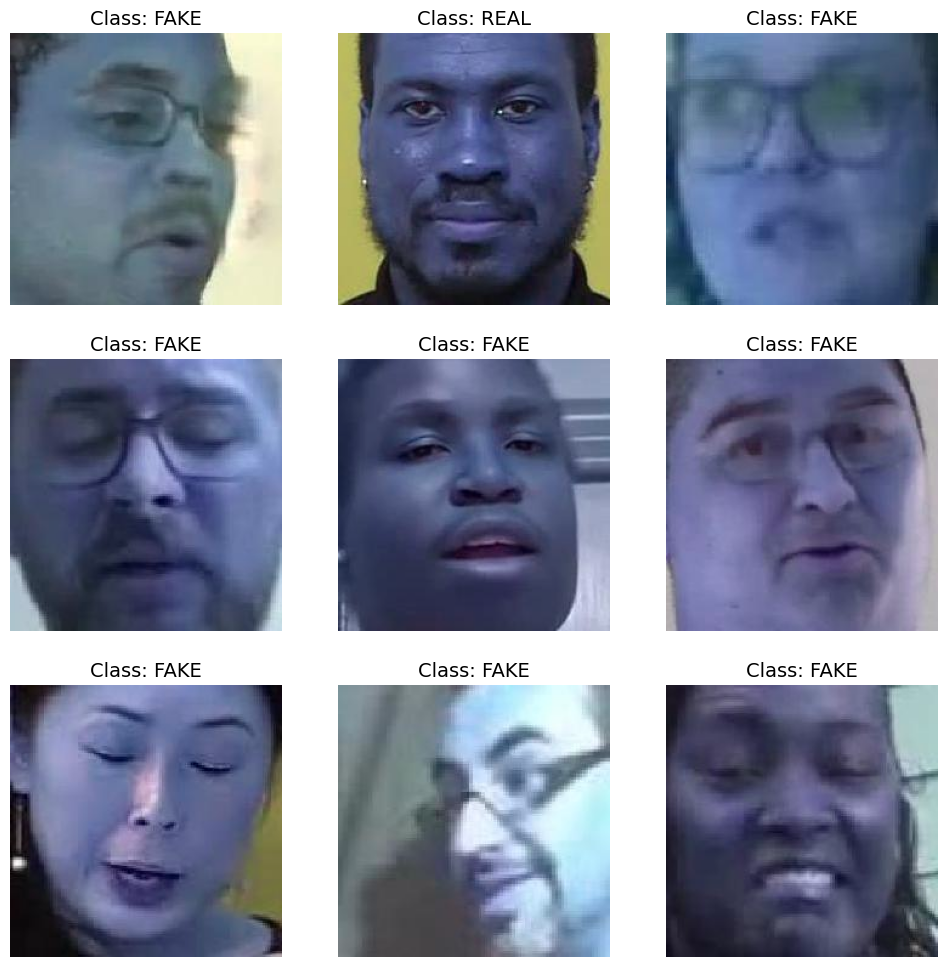

In [34]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        if(y_batch[index]==1):
            classt='FAKE'
        else:
            classt='REAL'
        plt.title(f"Class: {classt}")
        plt.axis("off")

plt.show()

In [35]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

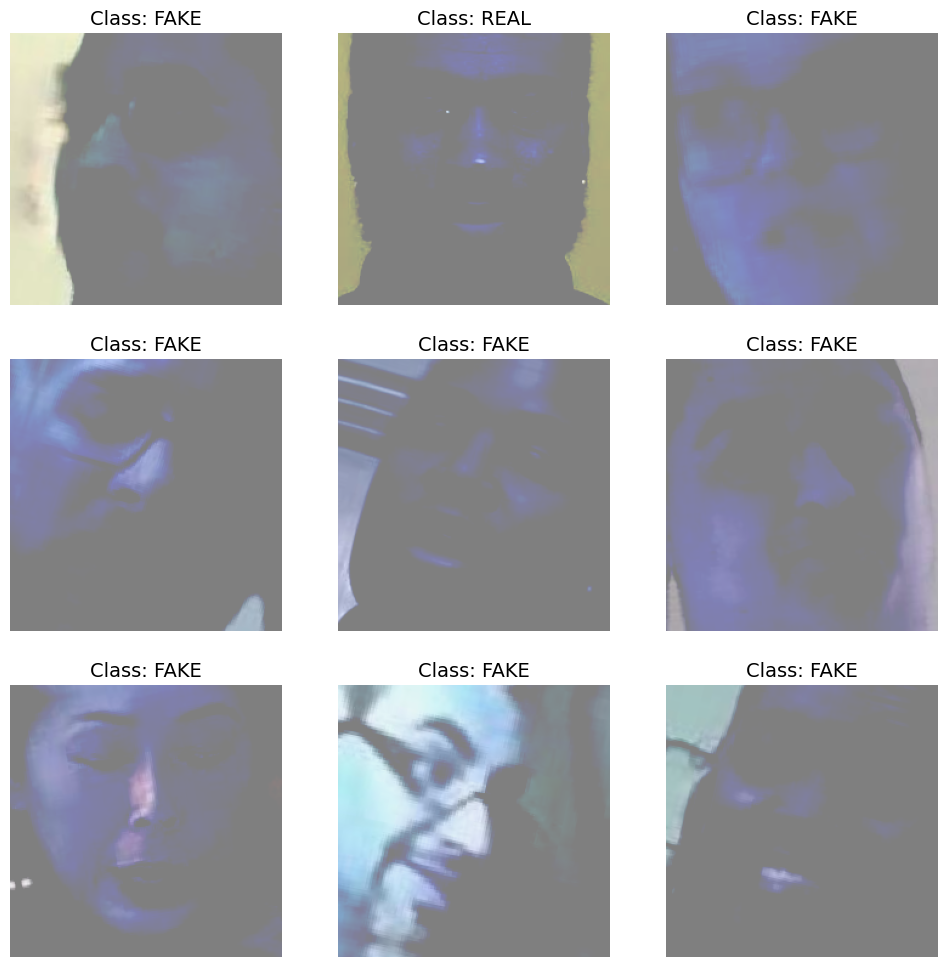

In [36]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        if(y_batch[index]==1):
            classt='FAKE'
        else:
            classt='REAL'
        plt.title(f"Class: {classt}")
        plt.axis("off")

plt.show()

In [1]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(1, activation="sigmoid")(avg)
model = tf.keras.Model(inputs=base_model.input, outputs=output)

NameError: name 'tf' is not defined

In [38]:
for layer in base_model.layers:
    layer.trainable = False

In [39]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
with strategy.scope():
    model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3


I0000 00:00:1726653255.771253     128 service.cc:145] XLA service 0x79a9c8004ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1726653255.772734     128 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1726653255.772749     128 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1726653266.475668     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1239/1239 - 191s - 154ms/step - accuracy: 0.6862 - loss: 0.7909 - val_accuracy: 0.4081 - val_loss: 1.6641
Epoch 2/3
1239/1239 - 161s - 130ms/step - accuracy: 0.6925 - loss: 0.8299 - val_accuracy: 0.7364 - val_loss: 0.8287
Epoch 3/3
1239/1239 - 162s - 131ms/step - accuracy: 0.7057 - loss: 0.7843 - val_accuracy: 0.7360 - val_loss: 0.5804


In [ ]:
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

In [40]:
model.evaluate(test_set)

365/365 ━━━━━━━━━━━━━━━━━━━━ 46s 123ms/step - accuracy: 0.7514 - loss: 0.5615


[0.5760246515274048, 0.7423449754714966]

Image batch shape: (4, 224, 224, 3)
Label batch shape: (4,)
Image batch dtype: <dtype: 'float32'>
Label batch dtype: <dtype: 'int64'>


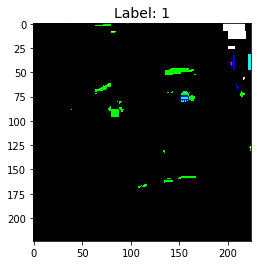

In [40]:
# Assuming 'dataset' is your BatchDataset object
for images, labels in test_set.take(4):  # Takes the first batch
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image batch dtype:", images.dtype)
    print("Label batch dtype:", labels.dtype)

    # Optionally visualize the first image in the batch (using matplotlib)
    import matplotlib.pyplot as plt

    plt.imshow(images[0].numpy().astype("uint8"))  # Convert to numpy and cast to uint8
    plt.title(f"Label: {labels[0].numpy()}")
    plt.show()


In [41]:
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
model.compile(loss="binary_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 340s 261ms/step - accuracy: 0.7715 - loss: 0.4858 - val_accuracy: 0.8621 - val_loss: 0.3133
Epoch 2/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 370s 257ms/step - accuracy: 0.8993 - loss: 0.2418 - val_accuracy: 0.8892 - val_loss: 0.2881
Epoch 3/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 322s 260ms/step - accuracy: 0.9446 - loss: 0.1360 - val_accuracy: 0.8771 - val_loss: 0.3467
Epoch 4/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 322s 260ms/step - accuracy: 0.9635 - loss: 0.0957 - val_accuracy: 0.8901 - val_loss: 0.3391
Epoch 5/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 321s 259ms/step - accuracy: 0.9739 - loss: 0.0684 - val_accuracy: 0.8939 - val_loss: 0.3801
Epoch 6/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 322s 260ms/step - accuracy: 0.9812 - loss: 0.0507 - val_accuracy: 0.8958 - val_loss: 0.3765
Epoch 7/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 322s 260ms/step - accuracy: 0.9860 - loss: 0.0407 - val_accuracy: 0.9031 - val_loss: 0.3469
Epoch 8/10
1239/1239 ━━━━━━━━━━━━━━━━━━━━ 321s 259ms/step - ac

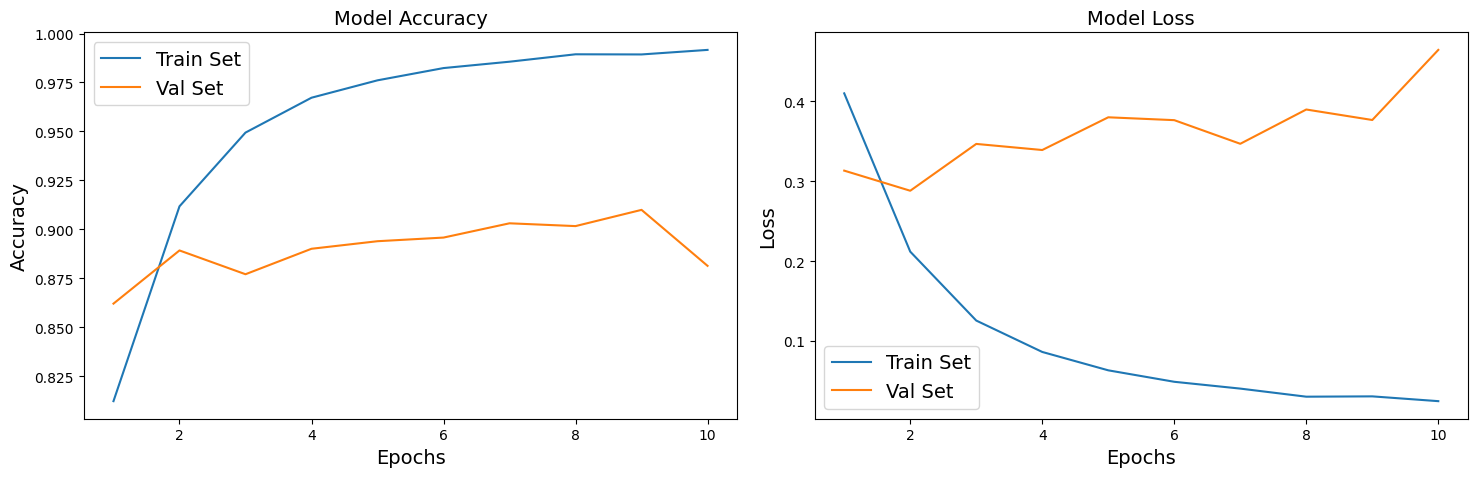

In [42]:
# plot model performance
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(history.epoch) + 1)

plt.figure(figsize=(15,5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Set')
plt.plot(epochs_range, val_acc, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Set')
plt.plot(epochs_range, val_loss, label='Val Set')
plt.legend(loc="best")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')

plt.tight_layout()
plt.show()

In [43]:
model.evaluate(test_set)

365/365 ━━━━━━━━━━━━━━━━━━━━ 41s 112ms/step - accuracy: 0.8782 - loss: 0.4843


[0.47737744450569153, 0.8760614395141602]

In [45]:
model.save('xception_deepfake_image_3o.h5')